In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.family'] = 'Arial'  # Set global font to Arial
#import numpy as np
import cartopy.feature as feature

In [28]:
#path_sm = '/g/data/jk72/sm3719/'
#path_cmip = 'cmip6'
#path_ds = '/pictrl/CSIRO-MK3-6-0/climate_index/eof/IOBM-IOD/eof2_CSIRO-Mk3-6-0-iobm_kave.nc'

#xr.open_dataset(path_sm + path_cmip)

In [29]:
ds1=xr.open_dataset('Regression_SLP_spatial_pattern_SAM_ERA5-23models.nc')
ds2=xr.open_dataset('Regression_SLP_spatial_pattern_SAM_MMM.nc')

SAM1=ds1['SLOPE'][0,:,:]
SAM2=ds1['SLOPE'][1,:,:]
SAM3=ds1['SLOPE'][2,:,:]
SAM4=ds1['SLOPE'][3,:,:]
SAM5=ds1['SLOPE'][4,:,:]
SAM6=ds1['SLOPE'][5,:,:]
SAM7=ds1['SLOPE'][6,:,:]
SAM8=ds1['SLOPE'][7,:,:]
SAM9=ds1['SLOPE'][8,:,:]
SAM10=ds1['SLOPE'][9,:,:]

print(ds1.coords)
#print(ds9)
#weight=ds9['clat']
#wslope1=slope1*weight
#weight.shape
print(ds1.coords)
LON = ds1.LON.data
LAT = ds1.LAT.data
LON=np.linspace(-180,180,360)
LAT=np.linspace(-90,-20,70)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)


Coordinates:
  * time     (time) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
  * LAT      (LAT) float64 560B -89.24 -88.25 -87.25 ... -22.44 -21.44 -20.44
Coordinates:
  * time     (time) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
  * LAT      (LAT) float64 560B -89.24 -88.25 -87.25 ... -22.44 -21.44 -20.44


In [30]:
SAM11=ds1['SLOPE'][10,:,:]
SAM12=ds1['SLOPE'][11,:,:]
SAM13=ds1['SLOPE'][12,:,:]
SAM14=ds1['SLOPE'][13,:,:]
SAM15=ds1['SLOPE'][14,:,:]
SAM16=ds1['SLOPE'][15,:,:]
SAM17=ds1['SLOPE'][16,:,:]
SAM18=ds1['SLOPE'][17,:,:]
SAM19=ds1['SLOPE'][18,:,:]
SAM20=ds1['SLOPE'][19,:,:]
SAM21=ds1['SLOPE'][20,:,:]
SAM22=ds1['SLOPE'][21,:,:]
SAM23=ds1['SLOPE'][22,:,:]
SAM24=ds1['SLOPE'][23,:,:]
SAM25=ds2['MMM'][:,:]


In [31]:
datasets = [
    (SAM1, "(a) ERA5 (EOF1-23.8%)"),
    (SAM2, "(b) CanESM5 (EOF1-20.3%)"),
    (SAM3, "(c) HadGEM3-GC31-LL (EOF1-26.2%)"),
    (SAM4, "(d) EC-Earth3-CC (EOF1-25.9%)"),
    (SAM5, "(e) CMCC-CM2-SR5 (EOF1-13.4%)"),
    (SAM6, "(f) CNRM-CM6-1 (EOF1-23.3%)"),
    (SAM7, "(g) GISS-E2-1-G (EOF1-45.0%)"),
    (SAM8, "(h) CMCC-ESM2 (EOF1-35.6%)"),
    (SAM9, "(i) EC-Earth3 (EOF1-27.3%)"),
    (SAM10, "(j) E3SM1-0 (EOF1-24.8%)"),
    (SAM11, "(k) MIROC6 (EOF1-35.0%)"),
    (SAM12, "(l) MRI-ESM2-0 (EOF1-28.6%)"),
    (SAM13, "(m) HadGEM3-GC31-MM (EOF1-21.6%)"),
    (SAM14, "(n) BCC-CSM2-MR (EOF1-20.6%)"),
    (SAM15, "(o) IPSL-CM6A-LR (EOF1-22.4%)"),
    (SAM16, "(p) MPI-ESM1-2-HR (EOF1-24.8%)"),
    (SAM17, "(q) ACCESS-ESM1-5 (EOF1-14.5%)"),
    (SAM18, "(r) ACCESS-CM2 (EOF1-29.0%)"),
    (SAM19, "(s) CESM2 (EOF1-21.7%)"),
    (SAM20, "(t) GFDL-CM4 (EOF1-24.0%)"),
    (SAM21, "(u) CIESM (EOF1-19.5%)"),
    (SAM22, "(v) FGOALS-g3 (EOF1-23.8%)"),
    (SAM23, "(w) SAM0-UNICON (EOF1-25.2%)"),
    (SAM24, "(x) CNRM-ESM2-1 (EOF1-30.6%)"),
    (SAM25, "(y) MMM")
]

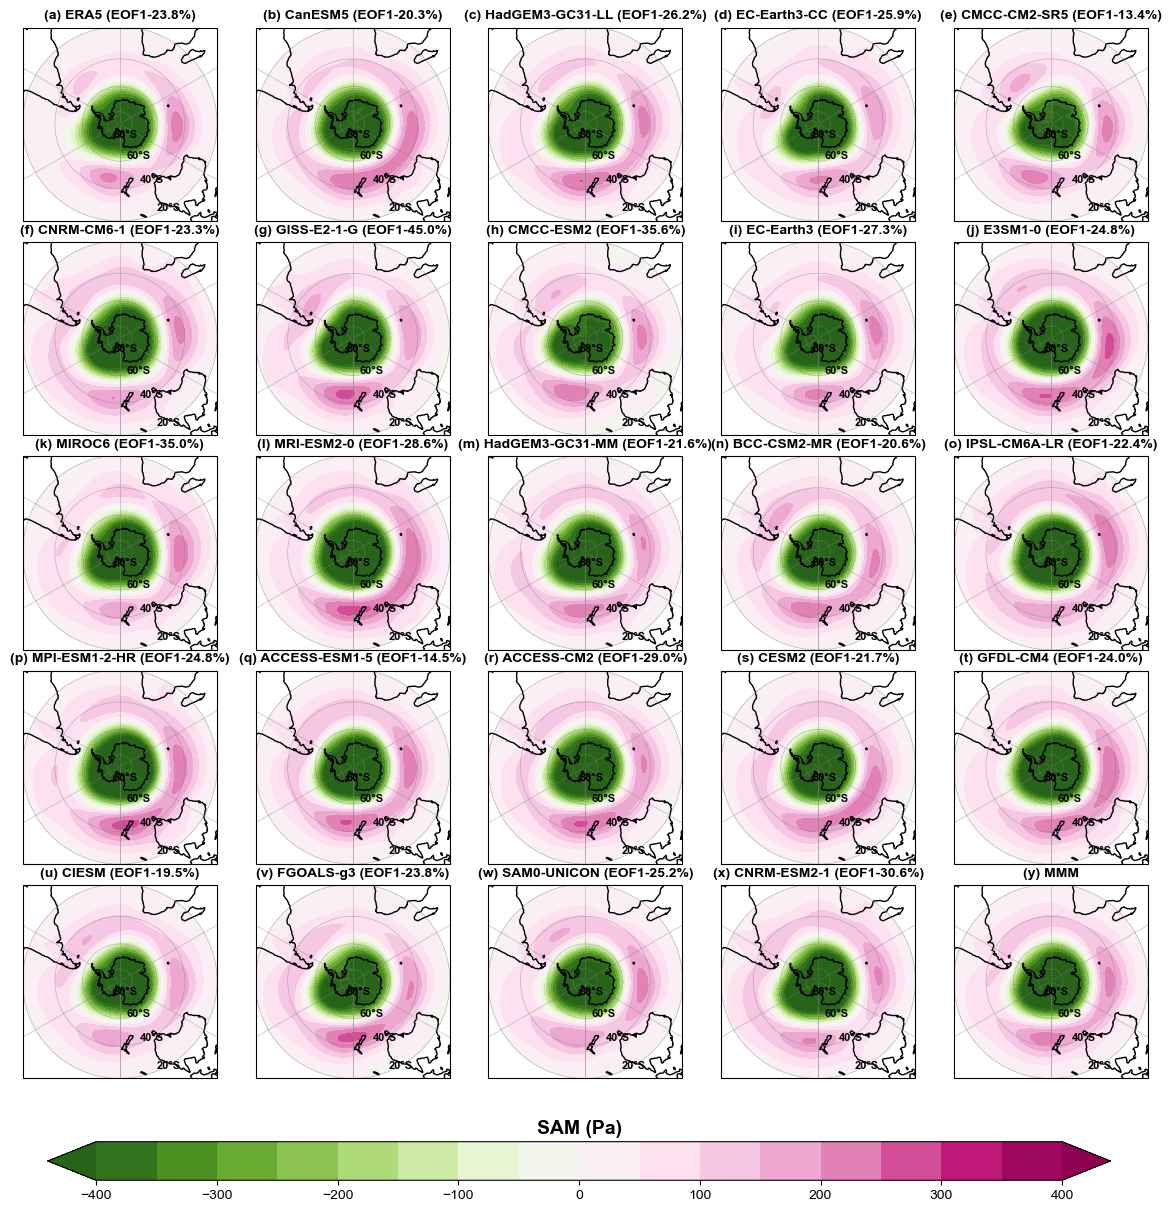

In [32]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.SouthPolarStereo(central_longitude=0)
clevs = np.arange(-400, 450, 50)

fig = plt.figure(figsize=(12.5, 19.3))
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(
        LON, LAT, data, levels=clevs, cmap=plt.cm.PiYG_r, 
        transform=ccrs.PlateCarree(), extend='both'
    )
    last_fill_sf = fill_sf
    ax.set_aspect('equal')
    ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')

    # Gridlines with longitude & latitude labels
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False   # show bottom longitude labels
    gl.left_labels = True     # show left latitude labels

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8, 'weight': 'bold'}
    gl.ylabel_style = {'size': 8, 'weight': 'bold'}

plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

if last_fill_sf is not None:
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('SAM (Pa)', loc='center', color='black', fontsize=14, fontweight='bold')
# Save and show plot 
plt.savefig('panel25_spherical_regression_SAM_observations_models_mmm.png', dpi=600)
plt.show()